In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os, sys
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

## Load data:

In [3]:
# fp_proc_moth_data = '/Users/tplas/data/2025-06-16 moth data Natalie/1994-2019_field-d50.csv'
fp_proc_moth_data = '/Users/tplas/data/2025-10-07 moth raw data 2023/Qry_D50_AllClutches_CommonGarden.xlsx'
assert os.path.exists(fp_proc_moth_data)

if fp_proc_moth_data.endswith('.csv'):
    df_proc = pd.read_csv(fp_proc_moth_data, sep=';')
elif fp_proc_moth_data.endswith('.xlsx'):
    df_proc = pd.read_excel(fp_proc_moth_data)
df_proc

,YearCatch,YearHatch,AreaShortName,Site,Tree,NovemberDate,TubeID,ExperimentName,D50Calc
0,1994,1995,HV,98,4,15,5944,CG1995,15.0
1,1994,1995,HV,98,44,15,5946,CG1995,8.0
2,1994,1995,HV,98,11,15,5947,CG1995,1.0
3,1994,1995,HV,98,41,15,5949,CG1995,8.0
4,1994,1995,HV,98,41,15,5950,CG1995,8.0
...,...,...,...,...,...,...,...,...,...
7392,2024,2025,WA,1,1,25,21382,CG2025,4.2
7393,2024,2025,WA,1,1,21,21383,CG2025,6.0
7394,2024,2025,WA,2,2,28,21385,CG2025,7.8
7395,2024,2025,WA,2,10,42,21386,CG2025,9.9


In [4]:
fp_raw_moth_data = '/Users/tplas/data/2025-10-07 moth raw data 2023/Qry_NumberOfCaterpillarsPerClutchPerDay.txt'
assert os.path.exists(fp_raw_moth_data)

## read as csv 
df_raw = pd.read_csv(fp_raw_moth_data, sep=';')
df_raw

,YearCatch,YearHatch,AreaShortName,Site,Tree,NovemberDate,TubeID,ExperimentName,AprilDay,Caterpillars
0,1994,1995,HV,98,4,15,5944,CG1995,-14,0.0
1,1994,1995,HV,98,4,15,5944,CG1995,-1,0.0
2,1994,1995,HV,98,4,15,5944,CG1995,5,0.0
3,1994,1995,HV,98,4,15,5944,CG1995,11,0.0
4,1994,1995,HV,98,4,15,5944,CG1995,19,30.0
...,...,...,...,...,...,...,...,...,...,...
119003,2024,2025,WA,2,12,25,21400,CG2025,10,6.0
119004,2024,2025,WA,2,12,25,21400,CG2025,16,8.0
119005,2024,2025,WA,2,12,25,21400,CG2025,17,1.0
119006,2024,2025,WA,2,12,25,21400,CG2025,22,0.0


## Re-calculate D50 for the raw data:

In [5]:
def add_relative_caterpillar_counts(df, remove_zero_tubes=True, min_num_caterpillars=10):
    df = df.copy()
    ## Add total caterpillars per tube:
    df_cp_per_tube = df.groupby(['TubeID']).agg({'Caterpillars':'sum'}).reset_index()
    df['TotalCaterpillarsPerTube'] = df['TubeID'].map(df_cp_per_tube.set_index('TubeID')['Caterpillars'])
    if remove_zero_tubes:
        df = df[df['TotalCaterpillarsPerTube'] > 0]
    if min_num_caterpillars is not None:
        df = df[df['TotalCaterpillarsPerTube'] >= min_num_caterpillars]

    ## Add (cumulative) relative caterpillar counts per tube:
    df['RelativeCaterpillarsPerTube'] = df['Caterpillars'] / df['TotalCaterpillarsPerTube']
    df['CumulativeRelativeCaterpillarsPerTube'] = df.groupby('TubeID')['RelativeCaterpillarsPerTube'].cumsum()
    return df 

df_raw = add_relative_caterpillar_counts(df_raw)
print(f"Number of unique tubes in raw data: {df_raw.TubeID.nunique()}")

Number of unique tubes in raw data: 7277


In [6]:
def calculate_d50(df, column='Caterpillars', verbose=0):
    assert 'TubeID' in df.columns and column in df.columns and 'AprilDay' in df.columns
    max_cp = int(df[column].max())
    if max_cp == 0.0:
        if verbose:
            print("WARNING: max_cp is 0.0"
                  f" for TubeID {df.TubeID.values[0]}")
        return np.nan
    
    if column == 'RelativeCaterpillarsPerTube':
        half_cp = 0.5
        max_cp = 1.0
    else:
        half_cp = max_cp / 2

    ## get the first day where the caterpillars are above half_cp
    df_half_top = df[df[column] >= half_cp]
    day_top = df_half_top.AprilDay.min()
    count_top = df_half_top[df_half_top.AprilDay == day_top][column].values[0]
    # count_top = df_half_top[column].min()
    # day_top = df_half_top[df_half_top[column] == count_top].AprilDay.values[0]

    ## get the last day where the caterpillars are below half_cp
    df_half_bottom = df[df[column] <= half_cp]
    if df_half_bottom.shape[0] == 0 or df_half_bottom[column].max() == 0.0:
        if verbose:
            print("WARNING: no bottom half found"
                f" for TubeID {df.TubeID.values[0]} with max_cp {max_cp}")
        return np.nan
    else:
        count_bottom = df_half_bottom[column].max()
        day_bottom = df_half_bottom[df_half_bottom[column] == count_bottom].AprilDay.values[0]

    if verbose:
        print(f"TubeID {df.TubeID.values[0]}: max_cp {max_cp}, half_cp {half_cp}, "
              f"day_bottom {day_bottom} (count_bottom {count_bottom}), "
              f"day_top {day_top} (count_top {count_top})")
        
    if count_top == count_bottom:
        if verbose:
            print(f"count_top == count_bottom for TubeID {df.TubeID.values[0]} with max_cp {max_cp}")
        return day_top
    
    # linear interpolation to find the day where the count is exactly half_cp
    d50 = day_bottom + (half_cp - count_bottom) * (day_top - day_bottom) / (count_top - count_bottom)
    return float(d50)

In [7]:
df_proc['RecalculatedD50'] = np.nan 
for i, row in df_proc.iterrows():
    tube_id = row['TubeID']
    if tube_id in df_raw.TubeID.values:
        d50_calc = calculate_d50(df_raw[df_raw.TubeID == tube_id], 
                                 column='CumulativeRelativeCaterpillarsPerTube', verbose=0)
        df_proc.at[i, 'RecalculatedD50'] = d50_calc

df_proc

,YearCatch,YearHatch,AreaShortName,Site,Tree,NovemberDate,TubeID,ExperimentName,D50Calc,RecalculatedD50
0,1994,1995,HV,98,4,15,5944,CG1995,15.0,NaN
1,1994,1995,HV,98,44,15,5946,CG1995,8.0,NaN
2,1994,1995,HV,98,11,15,5947,CG1995,1.0,1.000000
3,1994,1995,HV,98,41,15,5949,CG1995,8.0,NaN
4,1994,1995,HV,98,41,15,5950,CG1995,8.0,NaN
...,...,...,...,...,...,...,...,...,...,...
7392,2024,2025,WA,1,1,25,21382,CG2025,4.2,4.156863
7393,2024,2025,WA,1,1,21,21383,CG2025,6.0,5.980198
7394,2024,2025,WA,2,2,28,21385,CG2025,7.8,7.757576
7395,2024,2025,WA,2,10,42,21386,CG2025,9.9,9.933333


In [8]:
unique_tubes_raw_data = df_raw.TubeID.unique()
unique_tubes_proc_data = df_proc.TubeID.unique()

raw_tubes_not_in_proc = [tube for tube in unique_tubes_raw_data if tube not in unique_tubes_proc_data]
proc_tubes_not_in_raw = [tube for tube in unique_tubes_proc_data if tube not in unique_tubes_raw_data]

print(f"Tubes in raw data but not in processed data: {len(raw_tubes_not_in_proc)}, tubes in processed data but not in raw data: {len(proc_tubes_not_in_raw)}")

Tubes in raw data but not in processed data: 33, tubes in processed data but not in raw data: 0


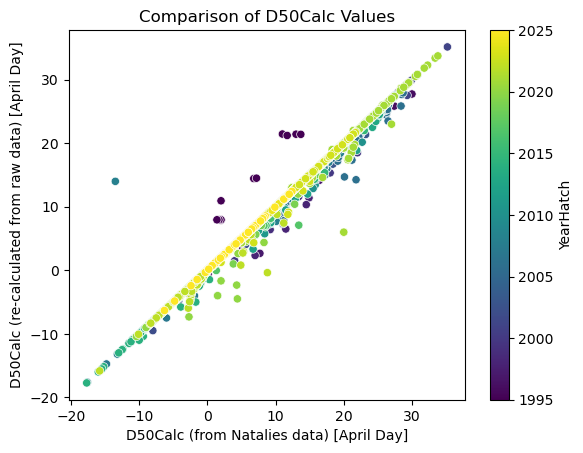

In [9]:
import matplotlib as mpl
cmap= sns.color_palette('viridis', as_cmap= True)
sm = plt.cm.ScalarMappable(cmap= cmap, norm=mpl.colors.Normalize())
sns.scatterplot(data=df_proc, x='D50Calc', y='RecalculatedD50', 
                hue='YearHatch', hue_norm=sm.norm, palette=cmap, legend=False)
                # hue='YearHatch', palette='viridis', alpha=0.7)
plt.xlabel('D50Calc (from Natalies data) [April Day]')
plt.ylabel('D50Calc (re-calculated from raw data) [April Day]')
plt.title('Comparison of D50Calc Values')
cbar = plt.colorbar(sm, ax = plt.gca(), label='YearHatch')


## Example tubes:

In [24]:
## Print all mismatched tubes:
mismatched_tubes = df_proc[np.abs(df_proc.D50Calc - df_proc.RecalculatedD50) > 1]
mismatched_tubes

,YearCatch,YearHatch,AreaShortName,Site,Tree,NovemberDate,TubeID,ExperimentName,D50Calc,RecalculatedD50
8,1994,1995,HV,98,48,15,5956,CG1995,2.0,7.909910
9,1994,1995,HV,98,41,18,5969,CG1995,11.0,21.449950
10,1994,1995,HV,98,41,18,5970,CG1995,13.0,21.424925
11,1994,1995,HV,98,41,18,5971,CG1995,11.7,21.224725
12,1994,1995,HV,98,41,18,5972,CG1995,13.7,21.399900
...,...,...,...,...,...,...,...,...,...,...
6830,2021,2022,OH,6,9,29,19050,CG2022,-2.3,-3.306306
7017,2022,2023,OH,2,9,21,19427,CG2023,6.8,4.333333
7088,2022,2023,OH,4,1,42,19564,CG2023,14.0,12.500000
7135,2022,2023,OH,5,2,35,19642,CG2023,11.9,9.137931


In [29]:
## Look at raw data for a specific tube:
tube_id = 5956

d50_original = df_proc[df_proc.TubeID == tube_id].D50Calc.values[0]
d50_recalculated = calculate_d50(df_raw[df_raw.TubeID == tube_id], column='CumulativeRelativeCaterpillarsPerTube', verbose=1)
print(f"\nOriginal D50 for TubeID {tube_id}: {np.round(d50_original, 2)}\nRe-calculated D50 for TubeID {tube_id}: {np.round(d50_recalculated, 2)}")


df_raw[df_raw.TubeID == tube_id]

TubeID 5956: max_cp 1, half_cp 0.5, day_bottom 5 (count_bottom 0.029154518950437316), day_top 11 (count_top 1.0)

Original D50 for TubeID 5956: 2.0
Re-calculated D50 for TubeID 5956: 7.91


,YearCatch,YearHatch,AreaShortName,Site,Tree,NovemberDate,TubeID,ExperimentName,AprilDay,Caterpillars,TotalCaterpillarsPerTube,RelativeCaterpillarsPerTube,CumulativeRelativeCaterpillarsPerTube
60,1994,1995,HV,98,48,15,5956,CG1995,-14,0.0,1029.0,0.000000,0.000000
61,1994,1995,HV,98,48,15,5956,CG1995,-1,0.0,1029.0,0.000000,0.000000
62,1994,1995,HV,98,48,15,5956,CG1995,5,30.0,1029.0,0.029155,0.029155
63,1994,1995,HV,98,48,15,5956,CG1995,11,999.0,1029.0,0.970845,1.000000
64,1994,1995,HV,98,48,15,5956,CG1995,19,0.0,1029.0,0.000000,1.000000
65,1994,1995,HV,98,48,15,5956,CG1995,24,0.0,1029.0,0.000000,1.000000


## Extapolate:

In [59]:
for tube_id in df_raw.TubeID.unique():
    df_tube = df_raw[df_raw.TubeID == tube_id]
    days_below_half = df_tube[df_tube.CumulativeRelativeCaterpillarsPerTube <= 0.5]
    if len(days_below_half) == 0:
        print(f"TubeID {tube_id}, year {df_tube.YearHatch.values[0]} has no days below half cumulative relative caterpillars.")

TubeID 6037, year 1995 has no days below half cumulative relative caterpillars.
TubeID 5196, year 2011 has no days below half cumulative relative caterpillars.
TubeID 5204, year 2011 has no days below half cumulative relative caterpillars.
TubeID 5205, year 2011 has no days below half cumulative relative caterpillars.
TubeID 5239, year 2011 has no days below half cumulative relative caterpillars.
TubeID 5244, year 2011 has no days below half cumulative relative caterpillars.
TubeID 5290, year 2011 has no days below half cumulative relative caterpillars.
TubeID 5291, year 2011 has no days below half cumulative relative caterpillars.
TubeID 5300, year 2011 has no days below half cumulative relative caterpillars.
TubeID 5351, year 2011 has no days below half cumulative relative caterpillars.
TubeID 5361, year 2011 has no days below half cumulative relative caterpillars.
TubeID 5374, year 2011 has no days below half cumulative relative caterpillars.
TubeID 5379, year 2011 has no days below

In [86]:
df_proc[df_proc.YearHatch == 2015]

,YearCatch,YearHatch,AreaShortName,Site,Tree,NovemberDate,TubeID,ExperimentName,D50Calc,RecalculatedD50
4381,2014,2015,DO,1,1,31,9606,CG2015,21.1,21.074074
4382,2014,2015,DO,5,3,31,9607,CG2015,15.2,15.210526
4383,2014,2015,DO,1,11,34,9689,CG2015,19.3,19.313253
4384,2014,2015,DO,1,1,38,9728,CG2015,22.5,22.461538
4385,2014,2015,DO,5,4,41,9977,CG2015,23.7,23.682540
...,...,...,...,...,...,...,...,...,...,...
4663,2014,2015,OH,5,9,47,10121,CG2015,21.3,21.294118
4664,2014,2015,OH,6,8,47,10124,CG2015,20.1,20.125000
4665,2014,2015,OH,4,6,53,10141,CG2015,16.2,NaN
4666,2014,2015,WA,3,7,31,9608,CG2015,19.3,19.275000


In [96]:
df_raw_year = df_raw[df_raw.YearHatch > 2020]
df_raw_year.AprilDay.unique()

array([ -8,  -5,  -1,   2,   5,   9,  13,  16,  20,  23,  27,  30,  33,
        36,  40,  42,  47, -29, -26, -22, -19, -15, -12,  -6,  -4,  -3,
        -2,   0,   1,   3,   4,   6,   7,   8,  10,  11,  12,  14,  15,
        17,  18,  19,  21,  22,  24,  25,  26,  28,  29,  31,  32,  34,
        35,  37,  38,  39,  41,  43,  44,  45,  46, -21, -17, -14, -10,
        -7, -16, -11])

<Axes: xlabel='AprilDay', ylabel='CumulativeRelativeCaterpillarsPerTube'>

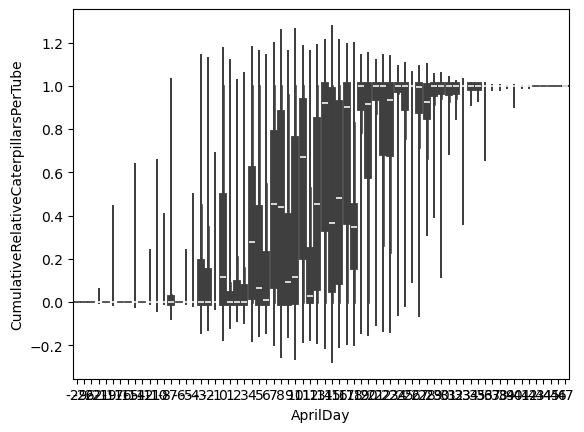

In [97]:

sns.violinplot(data=df_raw_year, x='AprilDay', y='CumulativeRelativeCaterpillarsPerTube')

np.int64(3)

In [103]:
from scipy.optimize import curve_fit
from tqdm import tqdm

tube_ids = df_raw_year.TubeID.unique()

dict_sigmoid_params = {x: [] for x in ['TubeID', 'x0', 'k']}
tube_ids_fail = []
## fit sigmoid to cumulative relative caterpillar counts
def sigmoid(x, x0, k):
    y = 1 / (1 + np.exp(-k*(x - x0)))
    return y

for tube_id in tqdm(tube_ids):
    df_tube = df_raw_year[df_raw_year.TubeID == tube_id]
    if df_tube.isna().sum().sum() > 0:
        print(f"Skipping TubeID {tube_id} with NaN values")
        continue
    max_count = df_tube.CumulativeRelativeCaterpillarsPerTube.max()
    if max_count < 0.8:
        print(f"Skipping TubeID {tube_id} with max cumulative relative count {max_count}")
        continue
    days_below_half = df_tube[df_tube.CumulativeRelativeCaterpillarsPerTube <= 0.5]
    if len(days_below_half) == 0:
        print(f"Skipping TubeID {tube_id} with no counts below or equal to 0.5")
        tube_ids_fail.append(tube_id)
        continue

    try:
        popt, pcov = curve_fit(sigmoid, df_tube.AprilDay, df_tube.CumulativeRelativeCaterpillarsPerTube, 
                               p0=[0, 1], maxfev=10000)
        dict_sigmoid_params['TubeID'].append(tube_id)
        dict_sigmoid_params['x0'].append(popt[0])
        dict_sigmoid_params['k'].append(popt[1])
    except RuntimeError as e:
        print(f"Could not fit sigmoid for TubeID {tube_id}: {e}")
df_sigmoid_params = pd.DataFrame(dict_sigmoid_params)
df_sigmoid_params
# print(f"Fitted parameters: x0={popt[0]}, k={popt[1]}, b={popt[2]}")

# x_fit = np.linspace(df_tube.AprilDay.min(), df_tube.AprilDay.max(), 100)
# y_fit = sigmoid(x_fit, *popt)   

# plt.scatter(df_tube.AprilDay, df_tube.CumulativeRelativeCaterpillarsPerTube, label='Data')
# plt.plot(x_fit, y_fit, color='red', label='Fitted Sigmoid')

 10%|█         | 143/1366 [00:01<00:12, 94.54it/s]

Could not fit sigmoid for TubeID 16670: Optimal parameters not found: Number of calls to function has reached maxfev = 10000.


 64%|██████▍   | 874/1366 [00:02<00:00, 1291.63it/s]

Skipping TubeID 18464 with NaN values
Skipping TubeID 18465 with NaN values
Skipping TubeID 18466 with NaN values
Skipping TubeID 18467 with NaN values
Skipping TubeID 18470 with NaN values
Skipping TubeID 18471 with NaN values
Skipping TubeID 18473 with NaN values
Skipping TubeID 18474 with NaN values
Skipping TubeID 18475 with NaN values
Skipping TubeID 18479 with NaN values
Skipping TubeID 18481 with NaN values
Skipping TubeID 18482 with NaN values
Skipping TubeID 18492 with NaN values
Skipping TubeID 18493 with NaN values
Skipping TubeID 18494 with NaN values
Skipping TubeID 18495 with NaN values
Skipping TubeID 18497 with NaN values
Skipping TubeID 18501 with NaN values
Skipping TubeID 18502 with NaN values
Skipping TubeID 18506 with NaN values
Skipping TubeID 18507 with NaN values
Skipping TubeID 18508 with NaN values
Skipping TubeID 18510 with NaN values
Skipping TubeID 18513 with NaN values
Skipping TubeID 18514 with NaN values
Skipping TubeID 18519 with NaN values
Skipping Tub

 81%|████████▏ | 1111/1366 [00:04<00:01, 248.70it/s]

...

/opt/anaconda3/envs/pymc_env/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/pymc_env/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/pymc_env/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/pymc_env/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/pymc_env/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/pymc_env/lib/python3.13/site-packages/pandas/core/array

Could not fit sigmoid for TubeID 21306: Optimal parameters not found: Number of calls to function has reached maxfev = 10000.
Skipping TubeID 21310 with no counts below or equal to 0.5


100%|██████████| 1366/1366 [00:07<00:00, 191.71it/s]

Could not fit sigmoid for TubeID 21352: Optimal parameters not found: Number of calls to function has reached maxfev = 10000.
Skipping TubeID 21406 with no counts below or equal to 0.5


,TubeID,x0,k
0,16314,9.901707,0.348672
1,16315,-2.359043,0.543640
2,16316,7.602500,0.326598
3,16317,3.554145,0.316719
4,16319,5.013345,0.326681
...,...,...,...
848,21382,4.082235,0.536984
849,21383,5.933753,0.959946
850,21385,7.949781,0.590469
851,21386,9.924941,0.657415


TubeID    16929.000000
x0           11.987384
k             0.457382
dtype: float64


(-30.0, 30.0)

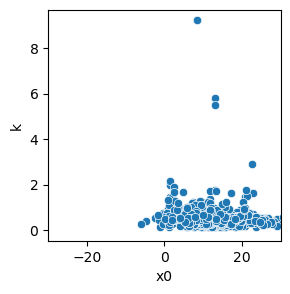

In [113]:
print(df_sigmoid_params.median())

fig, ax = plt.subplots(1, 1, figsize=(3, 3), gridspec_kw={'wspace':0.6})
sns.scatterplot(data=df_sigmoid_params, x='x0', y='k', ax=ax)
plt.xlim(-30, 30)

83

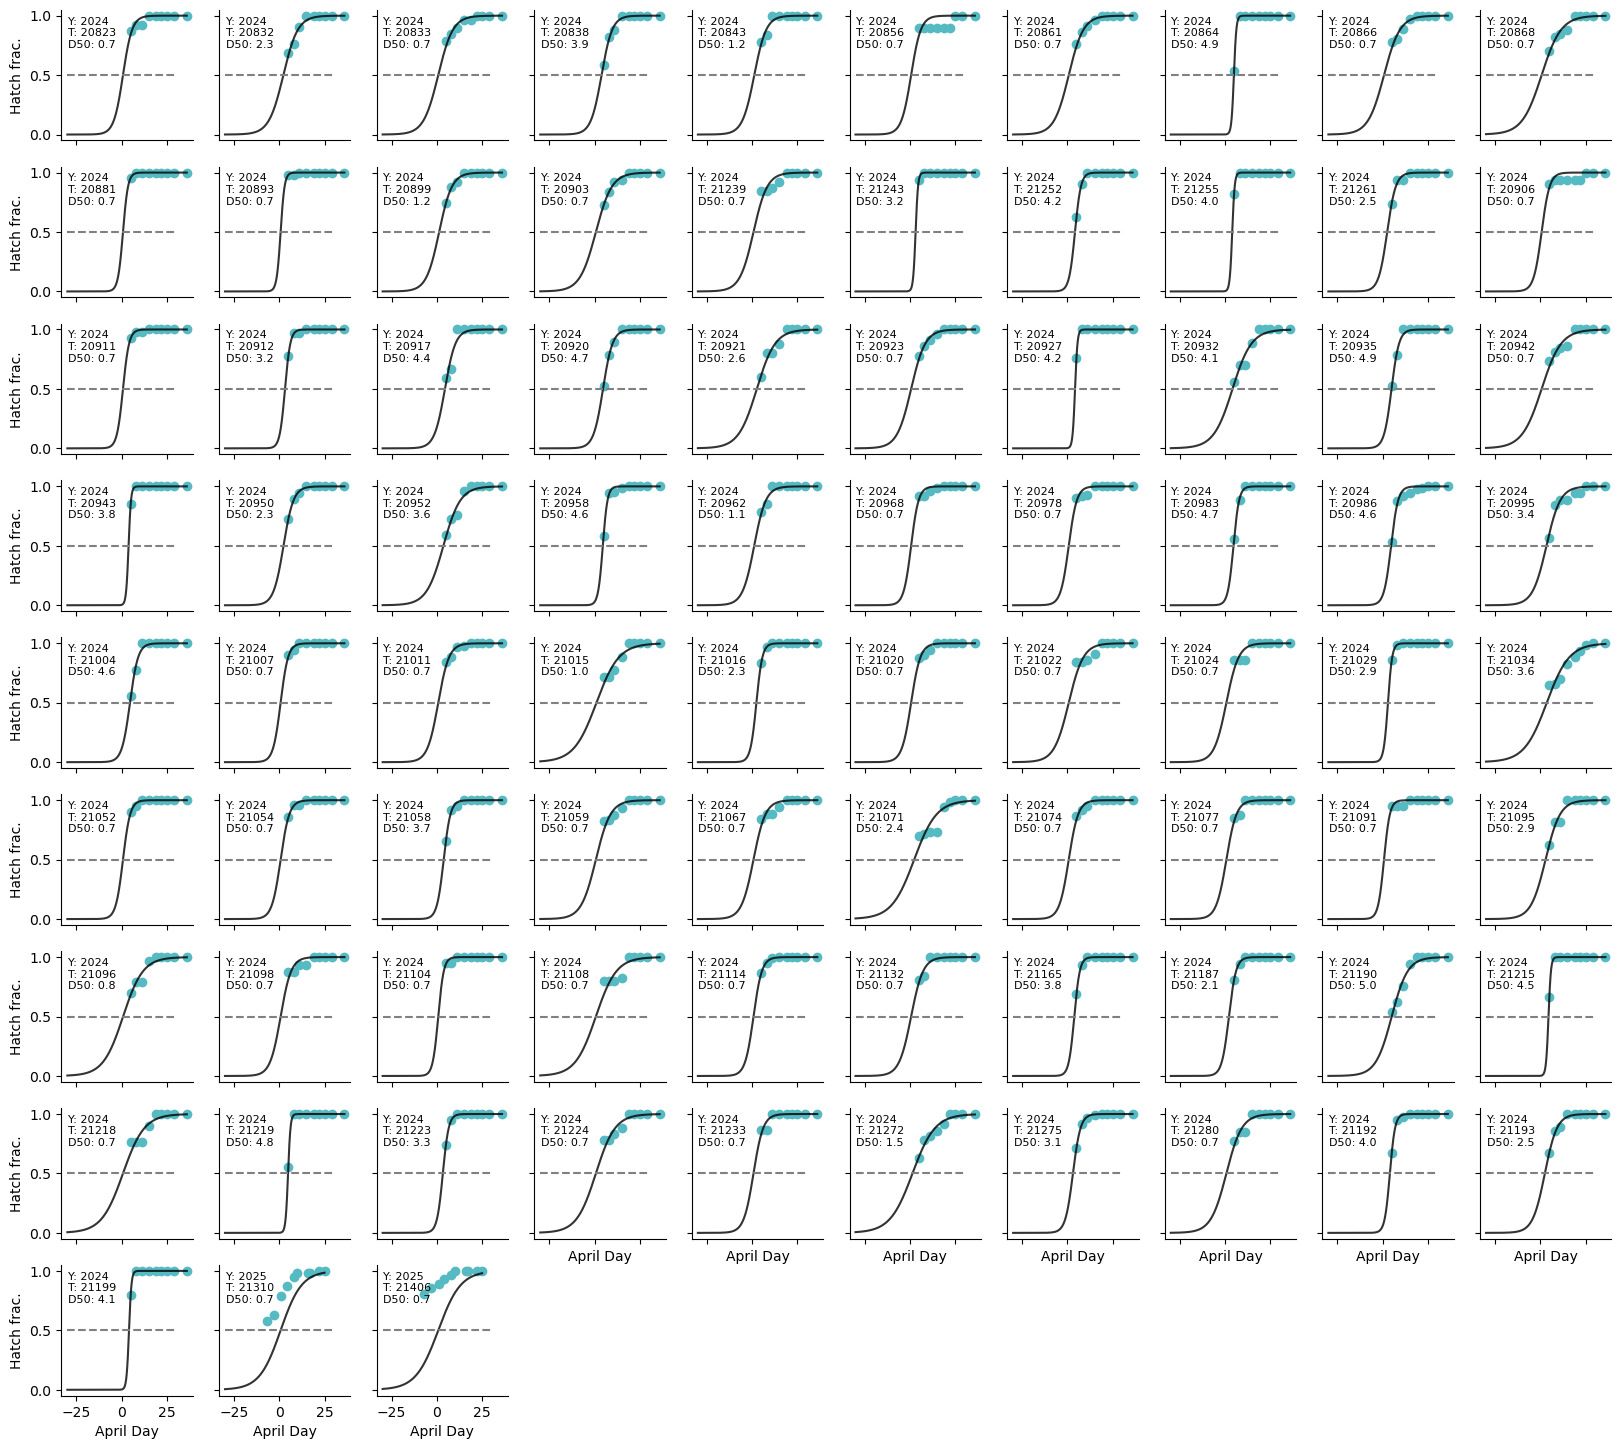

In [139]:
colors = sns.color_palette('tab10', n_colors=10)
point_estimates = (df_sigmoid_params.x0.median(), df_sigmoid_params.k.median())
hard_bounds_estimates = ((np.percentile(df_sigmoid_params.x0, 2), np.percentile(df_sigmoid_params.k, 2)),
                         (np.percentile(df_sigmoid_params.x0, 98), np.percentile(df_sigmoid_params.k, 98)))

n_plot = min(len(tube_ids_fail), 100)
n_cols = 10
n_rows = int(np.ceil(n_plot / n_cols))
fig, ax = plt.subplots(n_rows, n_cols, figsize=(n_cols*2, n_rows*2), squeeze=False, sharex=True, sharey=True)

for iloop, tube_id in enumerate(tube_ids_fail):
    df_tube = df_raw_year[df_raw_year.TubeID == tube_id]
    try:
        popt, pcov = curve_fit(sigmoid, df_tube.AprilDay, df_tube.CumulativeRelativeCaterpillarsPerTube, 
                               p0=point_estimates, bounds=(hard_bounds_estimates), maxfev=10000)
    except RuntimeError as e:
        print(f"Could not fit sigmoid for TubeID {tube_id} again: {e}")
        continue
    color = colors[iloop % 10]

    curr_ax = ax.flatten()[iloop]
    curr_ax.scatter(df_tube.AprilDay, df_tube.CumulativeRelativeCaterpillarsPerTube, color="#56bac3", alpha=1)
    x_fit = np.linspace(-30, df_tube.AprilDay.max(), 10000)
    y_fit = sigmoid(x_fit, *popt)
    d50 = x_fit[np.argmin(np.abs(y_fit - 0.5))]
    curr_ax.plot(x_fit, y_fit, color='k', alpha=0.8)
    # plt.title(f'TubeID {tube_id} - Failed Sigmoid Fit')
    curr_ax.hlines(0.5, xmin=-30, xmax=30, colors='gray', linestyles='dashed')
    curr_ax.annotate(f'Y: {df_tube.YearHatch.values[0]}\nT: {tube_id}\nD50: {d50:.1f}', 
                    xy=(0.05, 0.95), xycoords='axes fraction', fontsize=8, color='black', va='top')
    for sp in ['top', 'right']:
        curr_ax.spines[sp].set_visible(False)
    if iloop >= n_plot:
        break
    
for ii in range(n_plot, n_cols * n_rows):
    curr_ax = ax.flatten()[ii]
    curr_ax.axis('off')

for ii in range(n_rows):
    ax[ii][0].set_ylabel('Hatch frac.')
for jj in range(n_cols):
    if jj >= n_plot % n_cols:
        row_plot = -2 
    else:
        row_plot = -1
    ax[row_plot][jj].set_xlabel('April Day')

# curr_ax.xlabel('April Day')
# curr_ax.ylabel('Cumulative Relative Caterpillars Per Tube')
    

In [140]:
n_plot

83

In [132]:
np.argmin(np.abs(y_fit - 0.5))

np.int64(57)